# Neural Network - A Simple Perceptron | Assignment


1. What is Deep Learning? Briefly describe how it evolved and how it differs
from traditional machine learning.
   - Deep Learning is a part of machine learning that uses neural networks with many layers to learn patterns from large amounts of data. It evolved from artificial neural network research and became powerful due to big data and GPUs. Unlike traditional machine learning, deep learning automatically learns features without manual feature engineering.

2. Explain the basic architecture and functioning of a Perceptron. What are its
limitations?
   - A Perceptron is the simplest neural network model. It takes input values, multiplies them with weights, adds a bias, and passes the result through an activation function to produce an output. It learns by adjusting weights during training. Its limitation is that it can only solve linearly separable problems, not complex patterns.

3. Describe the purpose of activation function in neural networks. Compare
Sigmoid, ReLU, and Tanh functions.
   - Activation functions decide whether a neuron should activate or not and help neural networks learn complex patterns by adding non-linearity.

   - Sigmoid outputs values between 0 and 1 but can suffer from vanishing gradients.
   - Tanh outputs between −1 and 1 and is centered around zero.
   - ReLU outputs 0 or positive values and trains faster in deep networks.

4. What is the difference between Loss function and Cost function in neural
networks? Provide examples.
   - A loss function measures the error for a single training example. A cost function is the average of loss values over the whole dataset used to train the model.

   - Example: Mean Squared Error (MSE) and Cross-Entropy can be loss functions for one sample, while their average over all samples becomes the cost function.

5. What is the role of optimizers in neural networks? Compare Gradient
Descent, Adam, and RMSprop.
   - Optimizers help update the weights of a neural network to reduce the loss during training.

   - Gradient Descent updates weights using the slope of the loss function.
   - RMSprop adjusts learning rates using recent gradients for faster convergence.
   - Adam combines momentum and RMSprop, making it faster and more efficient for most deep learning problems.

In [1]:
#6 Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.
# Single Layer Perceptron for AND Gate using NumPy

import numpy as np

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,0,0,1])

weights = np.random.rand(2)
bias = np.random.rand()

def activation(x):
    return 1 if x >= 0 else 0

learning_rate = 0.1
epochs = 10

for epoch in range(epochs):
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = activation(linear_output)

        error = y[i] - y_pred

        weights = weights + learning_rate * error * X[i]
        bias = bias + learning_rate * error

print("Trained Weights:", weights)
print("Trained Bias:", bias)

print("\nTesting AND Gate:")
for i in range(len(X)):
    output = activation(np.dot(X[i], weights) + bias)
    print(X[i], "->", output)

Trained Weights: [0.17424805 0.4349045 ]
Trained Bias: -0.5493136021822417

Testing AND Gate:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


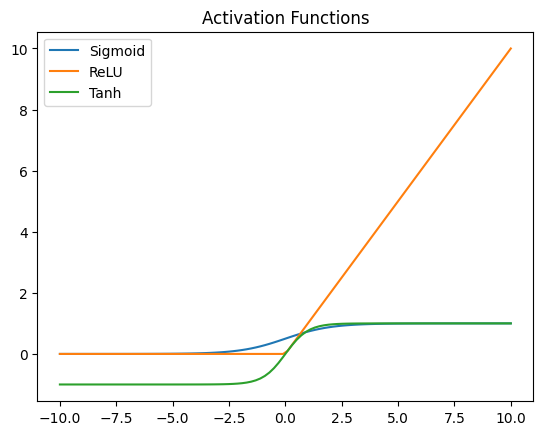

In [2]:
#7 Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)

sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, relu, label="ReLU")
plt.plot(x, tanh, label="Tanh")

plt.title("Activation Functions")
plt.legend()
plt.show()


In [5]:
#8 Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy
import tensorflow as tf
from tensorflow import keras
from keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = keras.Sequential([
    keras.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5)

print("Training Accuracy:", history.history['accuracy'][-1])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8797 - loss: 0.4321
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9640 - loss: 0.1220
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9768 - loss: 0.0794
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9828 - loss: 0.0570
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9870 - loss: 0.0432
Training Accuracy: 0.9864500164985657


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7801 - loss: 0.6332 - val_accuracy: 0.8517 - val_loss: 0.4157
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8623 - loss: 0.3862 - val_accuracy: 0.8621 - val_loss: 0.3845
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8777 - loss: 0.3369 - val_accuracy: 0.8725 - val_loss: 0.3586
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8820 - loss: 0.3199 - val_accuracy: 0.8715 - val_loss: 0.3550
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8926 - loss: 0.2891 - val_accuracy: 0.8711 - val_loss: 0.3542


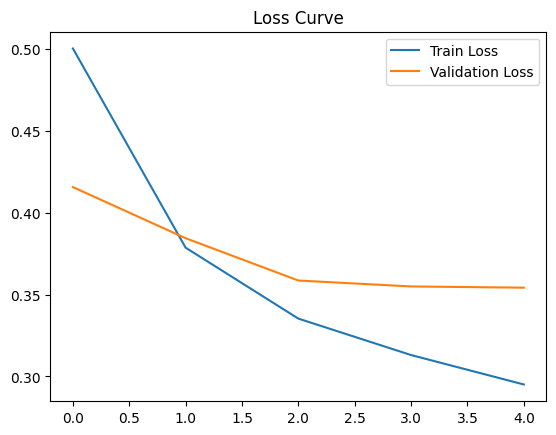

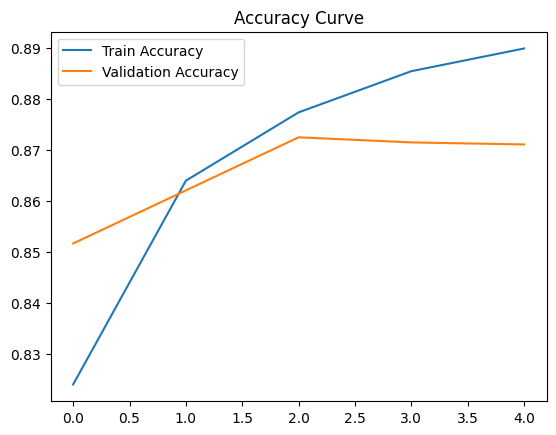

In [6]:
#9 Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior.

import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

Interpretation ->

During training, loss decreases while accuracy increases, showing that the model is learning patterns from the data. If training and validation curves are close, the model generalizes well. Large gaps between them may indicate overfitting.

10. You are working on a project for a bank that wants to automatically detect
fraudulent transactions. The dataset is large, imbalanced, and contains structured features like transaction amount, merchant ID, and customer location. The goal is to classify each transaction as fraudulent or legitimate.
Explain your real-time data science workflow:
   - How would you design a deep learning model (perceptron or multilayer NN)?
   - Which activation function and loss function would you use, and why?
   - How would you train and evaluate the model, considering class imbalance?
   - Which optimizer would be suitable, and how would you prevent overfitting?

Answer ->
1. Model Design
   - I would use a Multilayer Neural Network (MLP) because the data is structured. The input layer takes features like amount, merchant ID, and location. Then 2–3 hidden dense layers learn patterns, and the output layer has one neuron to classify the transaction as fraudulent or legitimate.

2. Activation & Loss Function -
   - ReLU in hidden layers for faster training and avoiding vanishing gradients.
   - Sigmoid in the output layer because it gives probability (0–1).
   - Use Binary Cross-Entropy loss since it is a binary classification problem.

3. Training & Evaluation
   - Because the dataset is imbalanced, I would use class weights or oversampling (SMOTE).
   - For evaluation, accuracy alone is not enough. I would use Precision, Recall, F1-score, and ROC-AUC to measure fraud detection performance.

4. Optimizer & Overfitting Prevention
   - I would use the Adam optimizer because it converges faster and adapts the learning rate.
   - To prevent overfitting, I would use dropout layers, early stopping, and regularization, and also validate the model on a separate validation dataset.